<a href="https://colab.research.google.com/github/mahiiipathak/ML-LAB-/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 4.63k/4.63k [00:00<00:00, 7.66MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1

--- 1. First 5 Records of Dataset ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4             

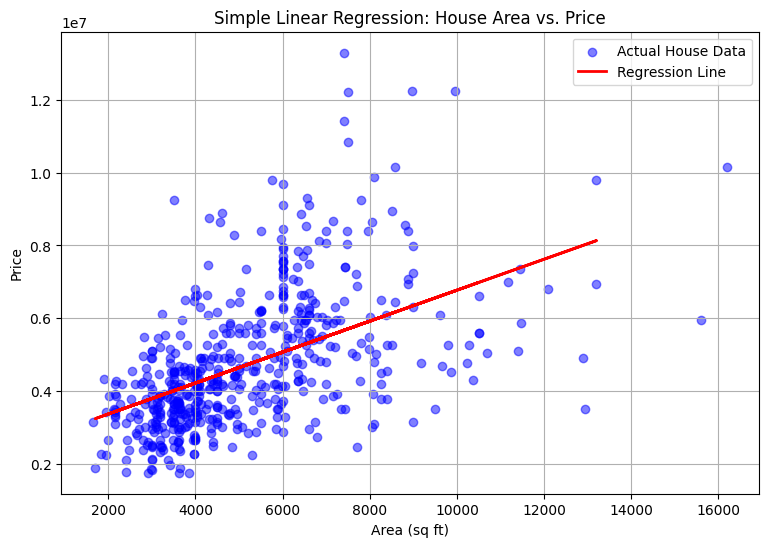

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub

# 1. Download dataset using kagglehub
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Path to dataset files:", path)

# Locate the CSV file inside the downloaded directory
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset directory.")

dataset_path = csv_files[0]

# Load dataset into Pandas DataFrame
df = pd.read_csv(dataset_path)

# 2. Display the dataset and identify variables
print("\n--- 1. First 5 Records of Dataset ---")
print(df.head())

print("\n--- Variable Identification ---")
print("Independent Variable (X): area")
print("Dependent Variable (y): price")

X = df[['area']]
y = df['price']

# 3. Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 4. Train a Simple Linear Regression model using Scikit-learn
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Display the learned slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print("\n--- Learned Parameters ---")
print(f"Slope (m)    : {slope:.4f}")
print(f"Intercept (c): {intercept:.4f}")
print(f"Regression Equation: Price = ({slope:.2f} * Area) + {intercept:.2f}")

# 6. Predict house prices for the testing dataset
y_pred = model.predict(X_test)

# Display sample predicted vs actual values
predictions_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print("\n--- First 5 Test Predictions ---")
print(predictions_df.head())

# 7. Compute and display evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")

# 8. Plot the regression line along with the original data points
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual House Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: House Area vs. Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()